<a href="https://colab.research.google.com/github/ankit-kr6/LEARNING-ML/blob/main/video_36.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!kaggle datasets download -d hesh97/titanicdataset-traincsv

Dataset URL: https://www.kaggle.com/datasets/hesh97/titanicdataset-traincsv
License(s): CC0-1.0
100% 22.0k/22.0k [00:00<00:00, 27.1MB/s]



In [3]:
import zipfile
with zipfile.ZipFile('titanicdataset-traincsv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
df=pd.read_csv('train.csv',usecols=['Survived','Age','Fare','SibSp','Parch'])

In [6]:
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [7]:
df['Family']=df['SibSp']+df['Parch']

In [8]:
# Method 2: In-place Override (Direct Memory Deletion)
df.drop(columns=['SibSp', 'Parch'], inplace=True)

In [9]:
df.head()

,Survived,Age,Fare,Family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [10]:
df.isnull().mean()

,0
Survived,0.000000
Age,0.198653
Fare,0.000000
Family,0.000000


In [11]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [12]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [14]:
x_train.isnull().mean()

,0
Age,0.196629
Fare,0.000000
Family,0.000000


In [15]:
mean_age=x_train['Age'].mean()
median_age=x_train['Age'].median()

In [16]:
x_train['Age_median']=x_train['Age'].fillna(median_age)
x_train['Age_mean']=x_train['Age'].fillna(mean_age)

In [17]:
x_train.sample(10)

,Age,Fare,Family,Age_median,Age_mean
297,2.0,151.5500,3,2.0,2.000000
484,25.0,91.0792,1,25.0,25.000000
862,48.0,25.9292,0,48.0,48.000000
737,35.0,512.3292,0,35.0,35.000000
603,44.0,8.0500,0,44.0,44.000000
125,12.0,11.2417,1,12.0,12.000000
809,33.0,53.1000,1,33.0,33.000000
582,54.0,26.0000,0,54.0,54.000000
490,NaN,19.9667,1,28.0,29.498846
356,22.0,55.0000,1,22.0,22.000000


In [18]:
print('original age variable variance:',x_train['Age'].var())
print('Age_median variable variance:',x_train['Age_median'].var())
print('Age_mean variable variance:',x_train['Age_mean'].var())

original age variable variance: 210.2517072477438
Age_median variable variance: 169.20731007048096
Age_mean variable variance: 168.8519336687225


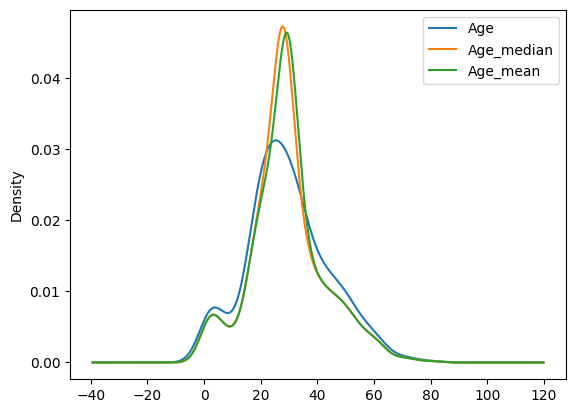

In [19]:
fig=plt.figure()
ax=fig.add_subplot(111)
x_train['Age'].plot(kind='kde',ax=ax)
x_train['Age_median'].plot(kind='kde',ax=ax)
x_train['Age_mean'].plot(kind='kde',ax=ax)
ax.legend(['Age','Age_median','Age_mean'])
plt.show()


In [20]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean
Age,210.251707,71.580633,-6.993325,210.251707,210.251707
Fare,71.580633,2700.831981,18.495747,61.261919,57.485994
Family,-6.993325,18.495747,2.830892,-5.587710,-5.616299
Age_median,210.251707,61.261919,-5.587710,169.207310,168.851934
Age_mean,210.251707,57.485994,-5.616299,168.851934,168.851934


In [21]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean
Age,1.000000,0.088103,-0.319651,1.000000,1.000000
Fare,0.088103,1.000000,0.211525,0.090622,0.085126
Family,-0.319651,0.211525,1.000000,-0.255307,-0.256883
Age_median,1.000000,0.090622,-0.255307,1.000000,0.998949
Age_mean,1.000000,0.085126,-0.256883,0.998949,1.000000


<Axes: >

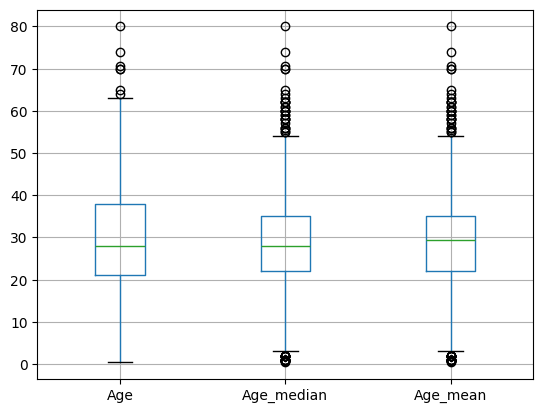

In [22]:
x_train[['Age','Age_median','Age_mean']].boxplot()

# using sklearn

In [23]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [24]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [25]:
trf=ColumnTransformer([
    ('first',imputer1,['Age'])
],remainder='passthrough')

In [29]:
trf.fit_transform(x_train)
trf.transform(x_test)

array([[ 42.    ,  26.2875,   0.    ],
       [ 21.    ,   8.05  ,   0.    ],
       [ 24.    ,  65.    ,   3.    ],
       [ 28.    ,  56.4958,   0.    ],
       [ 17.    ,   7.925 ,   6.    ],
       [ 30.    ,   7.8958,   0.    ],
       [ 80.    ,  30.    ,   0.    ],
       [ 25.    ,   7.25  ,   0.    ],
       [ 50.    , 133.65  ,   2.    ],
       [ 25.    ,  26.    ,   1.    ],
       [ 35.    ,  26.    ,   0.    ],
       [ 35.    ,  90.    ,   1.    ],
       [ 55.    ,  16.    ,   0.    ],
       [ 28.75  ,  56.4958,   0.    ],
       [ 28.75  ,  56.4958,   0.    ],
       [ 19.    ,   7.8542,   1.    ],
       [ 28.75  ,  15.2458,   2.    ],
       [ 49.    ,   0.    ,   0.    ],
       [ 18.    ,  14.4542,   1.    ],
       [ 65.    ,   7.75  ,   0.    ],
       [ 18.    , 108.9   ,   1.    ],
       [ 28.75  ,  22.3583,   2.    ],
       [ 16.    ,  18.    ,   2.    ],
       [ 21.    ,   9.825 ,   1.    ],
       [ 19.    ,   6.75  ,   0.    ],
       [  1.    ,  11.133

In [32]:
trf.named_transformers_['imputer1'].statistics_

KeyError: 'imputer1'